In [11]:
import glob
from pathlib import Path
from typing import Callable, Optional

import pandas as pd
import seaborn as sns
import numpy as np

### Preprocessing Validation

In [ ]:
# Read index from all parts matching a pattern and verify that the indexes do not overlap


def test_index_overlap(pattern: str):
    indexes = [set(pd.read_feather(f, columns=["kmer"]).index) for f in glob.glob(pattern)]

    print(f"Found {len(indexes)} indexes containing {sum(len(idx) for idx in indexes)} from files matching pattern: {pattern}")

    for i in range(len(indexes)):
        for j in range(i+1, len(indexes)):
            assert indexes[i].isdisjoint(indexes[j]), f"Indexes overlap detected"

In [7]:
test_index_overlap('../data/hamburg/joined-counts/Col_aColaLer.joined.part.*.feather')

Found 5 indexes containing 107442395 from files matching pattern: ../data/hamburg/joined-counts/Col_aColaLer.joined.part.*.feather


In [3]:
df = pd.read_feather('../data/hamburg/joined-counts/Col_ColLer.joined.index.feather')
df.shape

(76263426, 1)

In [6]:
df.dtypes

part    int64
dtype: object

### Correlation

In [2]:
df_g = pd.read_csv('../data/hamburg/cen-genotypes/C_LC.cen-genotype.csv', index_col=0)
df_g

,1,2,3,4,5
Sample,,,,,
C-LC-1,A,H,H,A,H
C-LC-10,A,H,H,H,H
C-LC-100,A,H,H,H,H
C-LC-101,H,H,A,H,A
C-LC-102,A,A,A,A,A
...,...,...,...,...,...
C-LC-95,H,H,H,A,A
C-LC-96,H,H,H,H,A
C-LC-97,A,H,A,A,A


In [3]:
# filter rows that contain value other than A or H
df_g = df_g[df_g.apply(lambda x: x.isin(['A', 'H']).all(), axis=1)]
print(pd.Series(df_g.values.flatten()).value_counts())
df_g

A    279
H    276
Name: count, dtype: int64


,1,2,3,4,5
Sample,,,,,
C-LC-1,A,H,H,A,H
C-LC-10,A,H,H,H,H
C-LC-100,A,H,H,H,H
C-LC-101,H,H,A,H,A
C-LC-102,A,A,A,A,A
...,...,...,...,...,...
C-LC-95,H,H,H,A,A
C-LC-96,H,H,H,H,A
C-LC-97,A,H,A,A,A


In [4]:
df_g.rename(index=lambda x: x.replace('-', '_'), inplace=True)
df_g

/tmp/ipykernel_3292628/1955428213.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_g.rename(index=lambda x: x.replace('-', '_'), inplace=True)


,1,2,3,4,5
Sample,,,,,
C_LC_1,A,H,H,A,H
C_LC_10,A,H,H,H,H
C_LC_100,A,H,H,H,H
C_LC_101,H,H,A,H,A
C_LC_102,A,A,A,A,A
...,...,...,...,...,...
C_LC_95,H,H,H,A,A
C_LC_96,H,H,H,H,A
C_LC_97,A,H,A,A,A


In [5]:
df_g = df_g.map(lambda x: {"A": 0, "H": 1}.get(x, x))
print(df_g.dtypes)
df_g

1    int64
2    int64
3    int64
4    int64
5    int64
dtype: object


,1,2,3,4,5
Sample,,,,,
C_LC_1,0,1,1,0,1
C_LC_10,0,1,1,1,1
C_LC_100,0,1,1,1,1
C_LC_101,1,1,0,1,0
C_LC_102,0,0,0,0,0
...,...,...,...,...,...
C_LC_95,1,1,1,0,0
C_LC_96,1,1,1,1,0
C_LC_97,0,1,0,0,0


In [6]:
df_meta = pd.read_csv('../PRJNA723952.SraRunTable.csv', index_col=['Run'])
df_meta.head()

,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Consent,DATASTORE filetype,...,LibrarySelection,LibrarySource,Organism,Platform,ReleaseDate,create_date,version,Sample Name,SRA Study,tissue
Run,,,,,,,,,,,,,,,,,,,,,
SRR14315885,WGS,300,231042600,PRJNA723952,SAMN18854919,Plant,99761957,UNIVERSITY OF CALIFORNIA DAVIS,public,"run.zq,sra,fastq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_ta_21,SRP315964,Leaf
SRR14315886,WGS,300,223972800,PRJNA723952,SAMN18854918,Plant,97450554,UNIVERSITY OF CALIFORNIA DAVIS,public,"fastq,sra,run.zq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_ta_20,SRP315964,Leaf
SRR14315887,WGS,300,224124900,PRJNA723952,SAMN18854624,Plant,96114811,UNIVERSITY OF CALIFORNIA DAVIS,public,"sra,fastq,run.zq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_aa_94,SRP315964,Leaf
SRR14315888,WGS,300,161992800,PRJNA723952,SAMN18854623,Plant,69335042,UNIVERSITY OF CALIFORNIA DAVIS,public,"sra,run.zq,fastq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_aa_93,SRP315964,Leaf
SRR14315889,WGS,300,222033000,PRJNA723952,SAMN18854621,Plant,94046947,UNIVERSITY OF CALIFORNIA DAVIS,public,"sra,run.zq,fastq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_aa_91,SRP315964,Leaf


In [7]:
df = pd.read_feather('../data/hamburg/joined-counts/Col_ColLer.joined.part.1.feather')
df.shape

(38133939, 110)

In [8]:
df.rename(columns=lambda run: df_meta.loc[run, 'Sample Name'], inplace=True)
df.columns

Index(['C_LC_29', 'C_LC_87', 'C_LC_83', 'C_LC_63', 'C_LC_92', 'C_LC_93',
       'C_LC_45', 'C_LC_54', 'C_LC_70', 'C_LC_82',
       ...
       'C_LC_79', 'C_LC_4', 'C_LC_108', 'C_LC_117', 'C_LC_52', 'C_LC_115',
       'C_LC_86', 'C_LC_37', 'C_LC_91', 'C_LC_119'],
      dtype='object', length=110)

In [9]:
df.drop(columns=[col for col in df.columns if col not in df_g.index], inplace=True)
df.shape

(38133939, 103)

In [10]:
df.fillna(0, inplace=True)

In [11]:
df = df[df.sum(axis=1) > 0]
df.shape

(35966853, 103)

In [12]:
df_t = df.transpose()
df_t.shape

(103, 35966853)

In [15]:
df_t_part = df_t.iloc[:, 0:10_000]
df_t_part.shape

(103, 10000)

In [20]:
df_corr = pd.DataFrame(index=df_t_part.columns)
df_corr.shape

(10000, 0)

In [21]:
for chr in df_g.columns:
    df_corr[chr] = df_t_part.corrwith(df_g[chr])

print(df_corr.shape)
df_corr.head()

(10000, 5)


,1,2,3,4,5
kmer,,,,,
AAAAAAAAAAAAAAAAAAAAAAG,0.007635,0.037383,-0.080028,-0.470359,-0.095074
AAAAAAAAAAAAAAAAAAAAAAT,0.095866,-0.032075,-0.163477,-0.035904,-0.214911
AAAAAAAAAAAAAAAAAAAAACG,0.062797,-0.067435,0.083978,0.001512,-0.026108
AAAAAAAAAAAAAAAAAAAAAGG,-0.069464,-0.067622,-0.049354,-0.472716,-0.068523
AAAAAAAAAAAAAAAAAAAAATT,0.046433,-0.024341,-0.170101,0.122011,-0.097482


In [22]:
df_corr.dtypes

1    float64
2    float64
3    float64
4    float64
5    float64
dtype: object

In [25]:
df_g.dtypes

1    int64
2    int64
3    int64
4    int64
5    int64
dtype: object

In [26]:
df_t_part.dtypes

kmer
AAAAAAAAAAAAAAAAAAAAAAG    float32
AAAAAAAAAAAAAAAAAAAAAAT    float32
AAAAAAAAAAAAAAAAAAAAACG    float32
AAAAAAAAAAAAAAAAAAAAAGG    float32
AAAAAAAAAAAAAAAAAAAAATT    float32
                            ...   
AAAAAAAAAAAGACACTAATTGT    float32
AAAAAAAAAAAGACACTGATTGC    float32
AAAAAAAAAAAGACAGAAACAAC    float32
AAAAAAAAAAAGACAGATGTGTG    float32
AAAAAAAAAAAGACAGCGGAAAA    float32
Length: 10000, dtype: object

In [7]:
def correlate_kmers_with_genotypes(
    metadata_csv_path: Path | str,
    genotype_csv_path: Path | str,
    kmer_count_feather_path: Path | str,
    kmer_filter: Optional[Callable[[pd.DataFrame], pd.DataFrame]] = None,
) -> pd.DataFrame:
    df_meta = pd.read_csv(metadata_csv_path, index_col=['Run'])

    df_g = pd.read_csv(genotype_csv_path, index_col=0)
    df_g = df_g[df_g.apply(lambda x: x.isin(['A', 'H']).all(), axis=1)]
    df_g.rename(index=lambda x: x.replace('-', '_'), inplace=True)
    df_g = df_g.map(lambda x: {"A": 0, "H": 1}.get(x, x))

    df = pd.read_feather(kmer_count_feather_path)
    df.rename(columns=lambda run: df_meta.loc[run, 'Sample Name'], inplace=True)
    df.drop(columns=[col for col in df.columns if col not in df_g.index], inplace=True)
    df.fillna(0, inplace=True)
    df = df[df.sum(axis=1) > 0]

    if kmer_filter is not None:
        df = kmer_filter(df)

    df_t = df.transpose()
    df_corr = pd.DataFrame(index=df_t.columns)

    for chr in df_g.columns:
        df_corr[chr] = df_t.corrwith(df_g[chr]).astype('float32')

    return df_corr

In [16]:
df_corr = correlate_kmers_with_genotypes(
    metadata_csv_path='../PRJNA723952.SraRunTable.csv',
    genotype_csv_path='../data/hamburg/cen-genotypes/C_LC.cen-genotype.csv',
    kmer_count_feather_path='../data/hamburg/joined-counts/Col_ColLer.joined.part.1.feather',
    kmer_filter=lambda df: df.sample(8192),
)

print(df_corr.shape)
print(df_corr.dtypes)

df_corr.head()

(8192, 5)
1    float32
2    float32
3    float32
4    float32
5    float32
dtype: object


,1,2,3,4,5
kmer,,,,,
AGATCTAAAACTCTGAGACTGAA,0.001238,-0.009701,-0.029295,-0.119103,0.015017
AAAAACAACAAACTTCGCAGCAT,-0.095765,-0.079761,0.073432,0.045636,0.135247
GACTGGCAATTTTTTGTCAAGAC,0.096655,-0.127805,0.066984,-0.049020,-0.078414
AAAGTAATACTCCCTCTTTTGCC,0.101942,-0.103944,-0.124263,0.116961,0.112411
GTTTGATAGTTTTTTACAGGGTA,-0.096172,0.094319,-0.124263,-0.083822,-0.087215


Text(0.5, 1.0, 'Correlation Distribution')

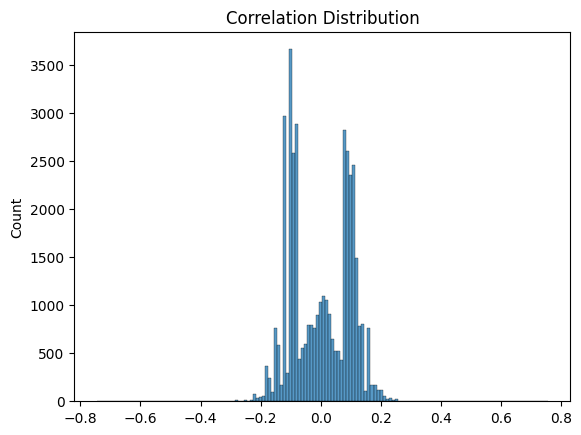

In [17]:
sns.histplot(df_corr.values.flatten(), binwidth=0.01).set_title("Correlation Distribution")

Text(0.5, 1.0, 'Correlation Distribution')

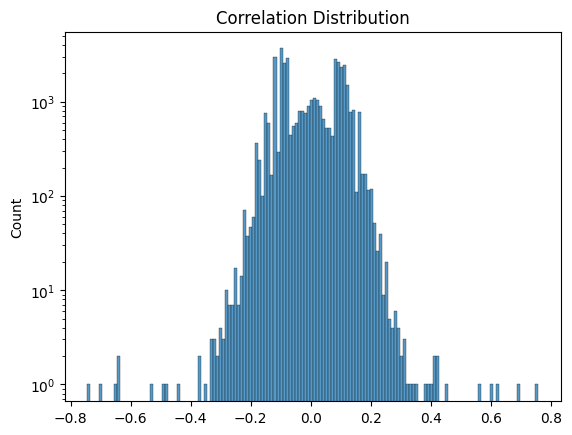

In [18]:
plt = sns.histplot(df_corr.values.flatten(), binwidth=0.01)
plt.set_yscale("log")
plt.set_title("Correlation Distribution")

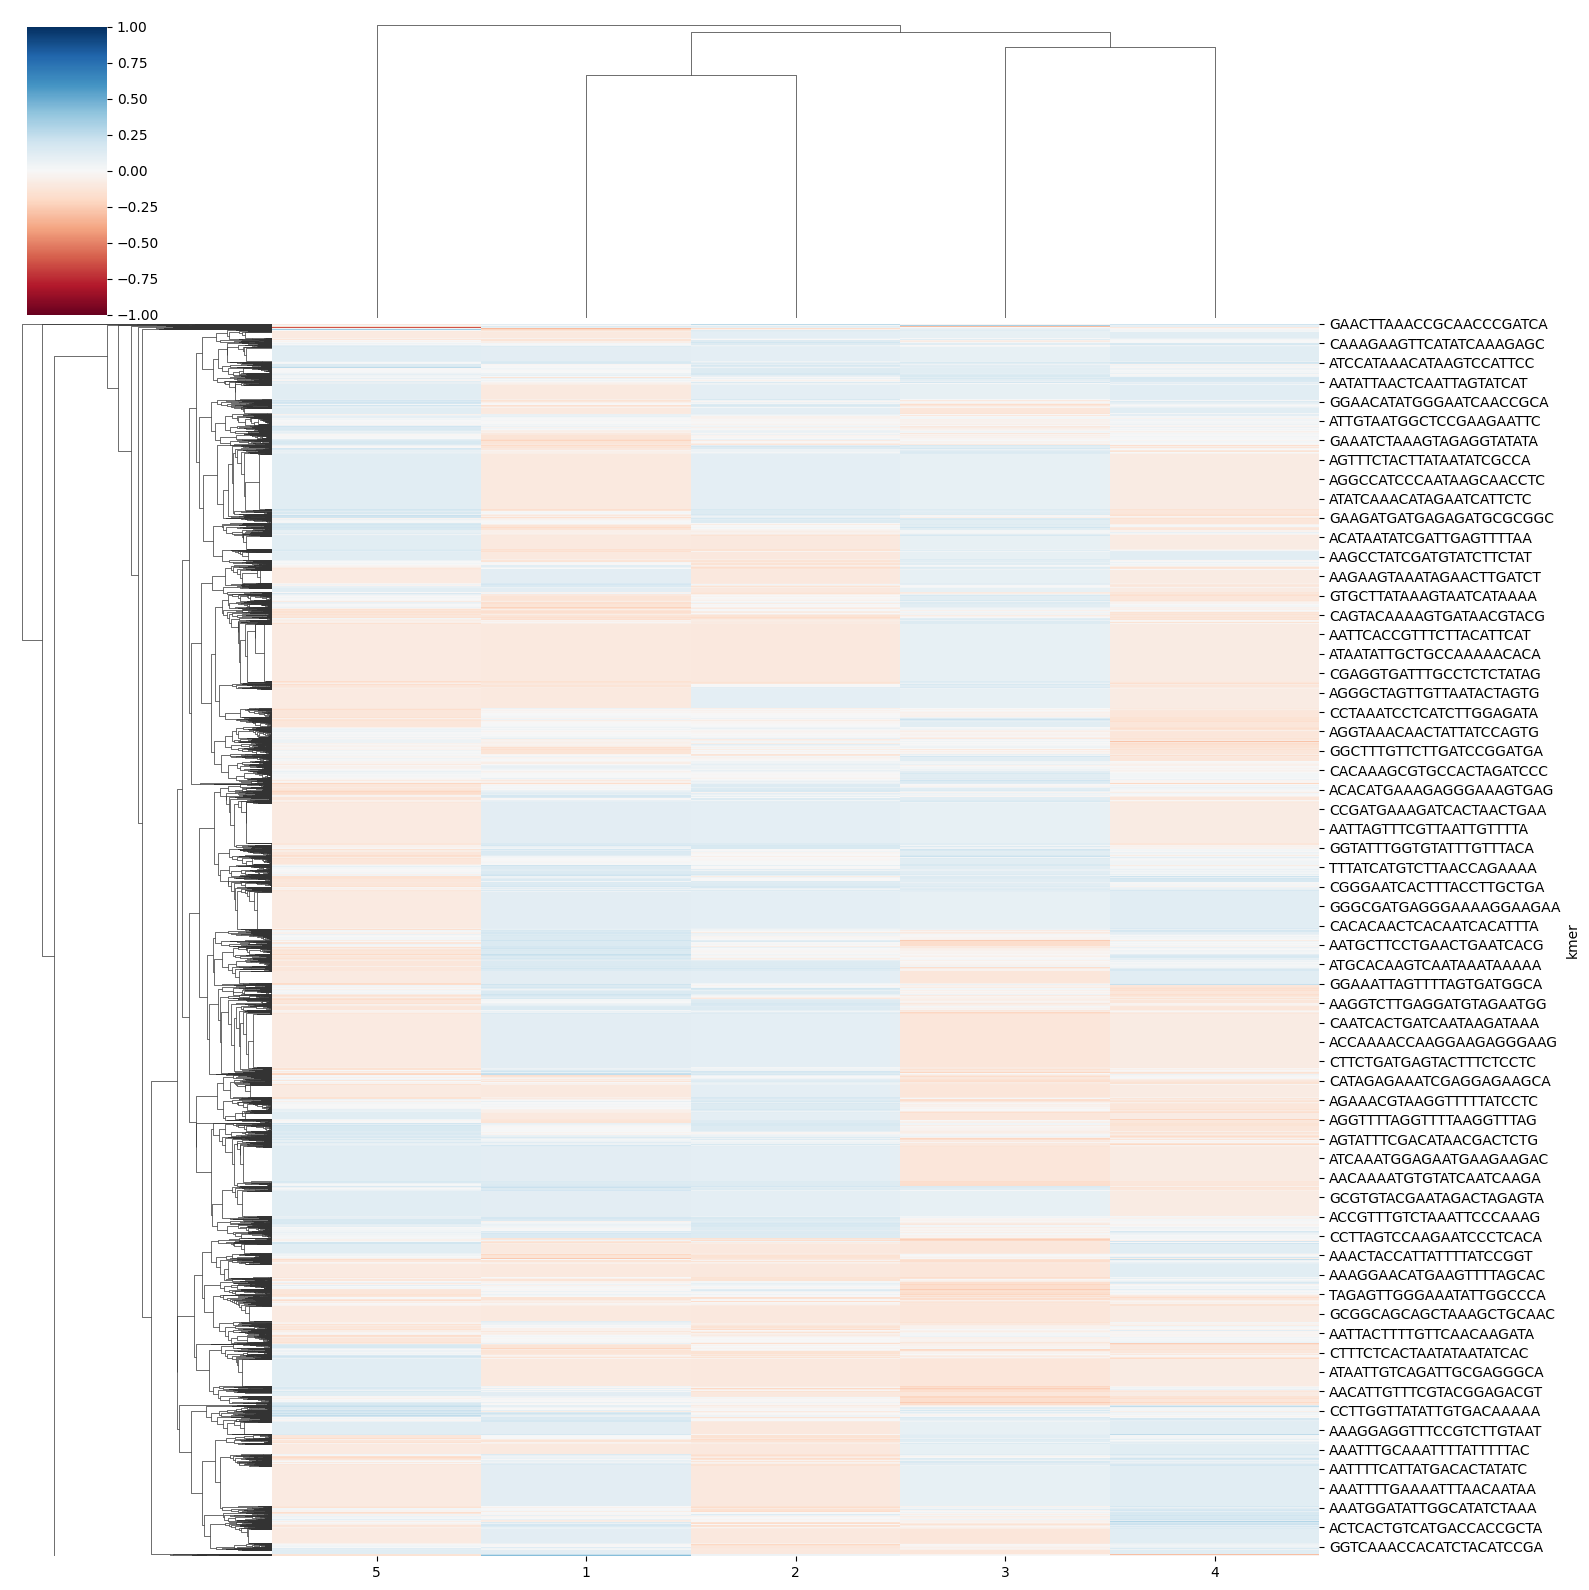

In [19]:
sns.clustermap(
    df_corr,
    cmap="RdBu",
    figsize=(16, 16),
    vmin=-1,
    vmax=1,
)